# Insurance Charges Prediction

This notebook analyzes the `insurance.csv` dataset and builds a linear regression model to predict medical insurance charges from demographic and health-related variables. The workflow covers data inspection, cleaning, exploratory data analysis, feature engineering, model training, evaluation, and interpretation.


## Part 1 - Setup and data loading

The analysis uses common Python data science libraries. The dataset is loaded from a local file named `insurance.csv`, so the notebook is portable and does not depend on Google Drive mounting.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11


In [7]:
data_path = Path('insurance.csv')
if not data_path.exists():
    raise FileNotFoundError("Place 'insurance.csv' in the same folder as this notebook before running all cells.")

df = pd.read_csv(data_path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Part 2 - Initial inspection

This section checks the dataset structure, variable types, missing values, and duplicate rows before any analysis is performed.


In [ ]:
print(f'Shape: {df.shape}')
print('Data types:')
print(df.dtypes)
print('Missing values:')
print(df.isna().sum())
print(f"Duplicate rows: {df.duplicated().sum()}")


Shape: (1338, 7)
Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicate rows: 1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Cleaning

The dataset contains one duplicate row and no missing values. The duplicate row is removed so that each observation represents a unique insurance record.


There is one duplicated row so cleaning this

In [ ]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df.drop_duplicates(inplace=True)

## Part 3 - Descriptive statistics

A quick summary helps describe the sample and the scale of the target variable.


In [ ]:
avg_charge = df['charges'].mean()
min_charge = df['charges'].min()
max_charge = df['charges'].max()

print(f"The average insurance charge is {avg_charge:.2f} USD.")
print(f"The minimum charge is {min_charge:.2f} USD and the maximum is {max_charge:.2f} USD.")

avg_age = df['age'].mean()
avg_bmi = df['bmi'].mean()

print(f"The average age is {avg_age:.2f}")
print(f"The average bmi is {avg_bmi:.2f}")

The average insurance charge is 13270.42 USD.
The minimum charge is 1121.87 USD and the maximum is 63770.43 USD.
The average age is 39.21
The average bmi is 30.66


## Part 4 - Exploratory data analysis

The main goal of this section is to understand how charges vary across key features such as smoking status, age, BMI, and region.


In [ ]:
df['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [ ]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [ ]:
df.corr(numeric_only=True)['charges'].sort_values(ascending=False)


,charges
charges,1.000000
age,0.298308
bmi,0.198401
children,0.067389


The simple numeric correlations show that age and BMI have positive relationships with charges, while the number of children has a much weaker linear association. Smoking status is categorical, so it is better examined separately rather than through the numeric-only correlation table.


In [ ]:
df.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8440.660307
yes,32050.231832


Smoking status appears most strongly related to insurance charges. The mean charges for smokers are several times higher than for non‑smokers

### Quickplot pairs
Quick plot for sanity check. there appears to be correlation between charges and some other variables


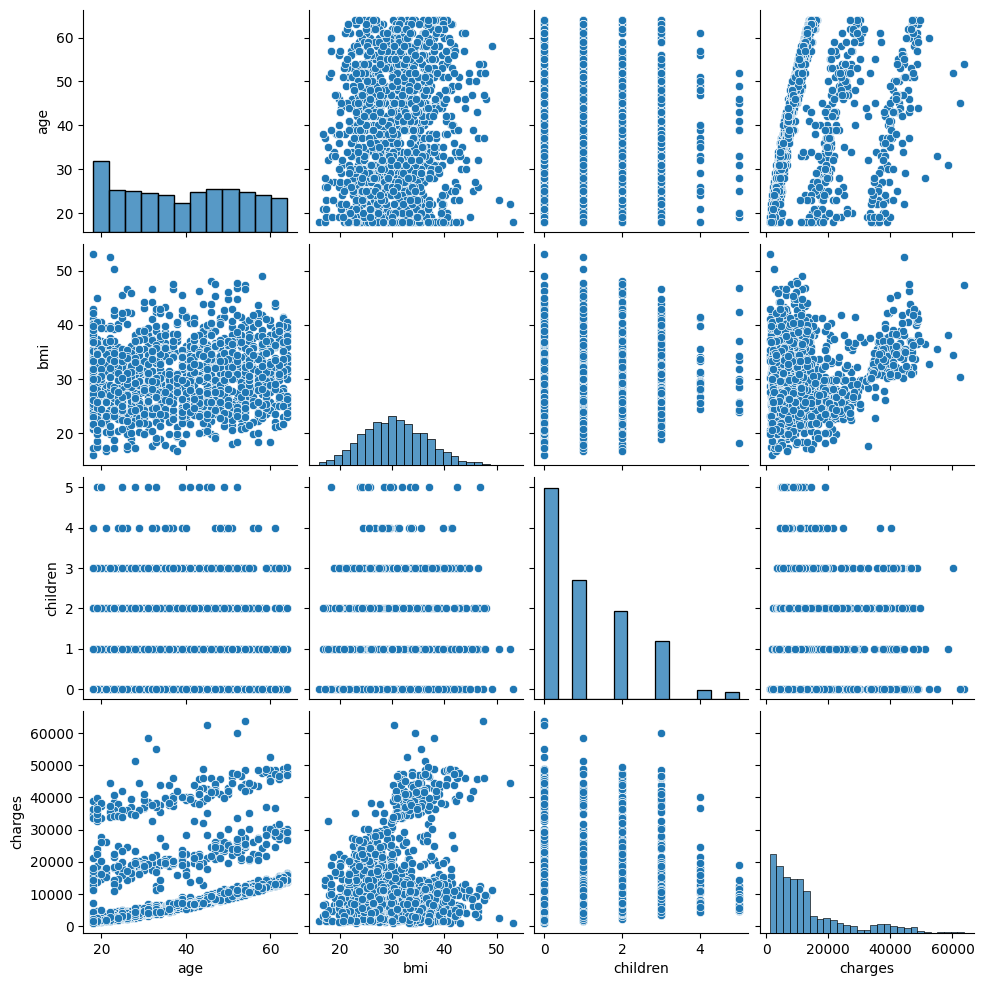

In [ ]:
sns.pairplot(df)

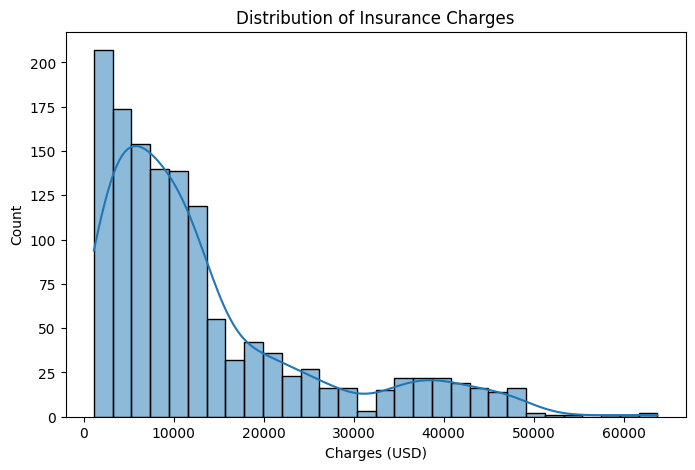

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges (USD)')
plt.ylabel('Count')
plt.show()

Charges are right-skewed: most policyholders have relatively low to moderate charges. This suggests that a smaller number of individuals incur very high medical costs.

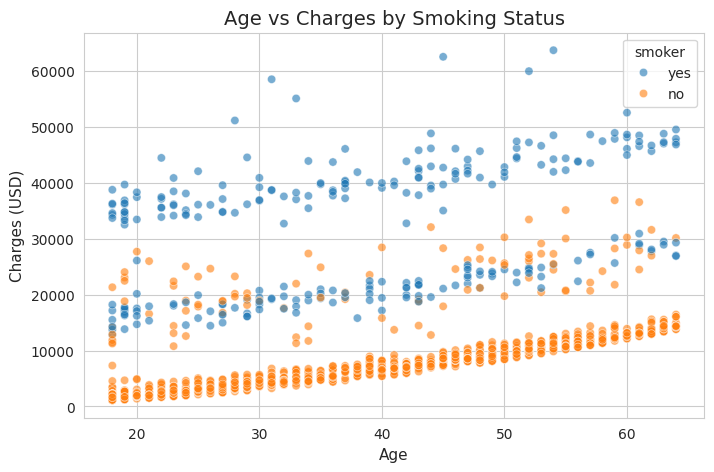

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('Age vs Charges by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.show()

Charges generally increase with age, although the relationship is moderate and shows substantial spread. There appears to be a stronger positive correlation for non-smokers.

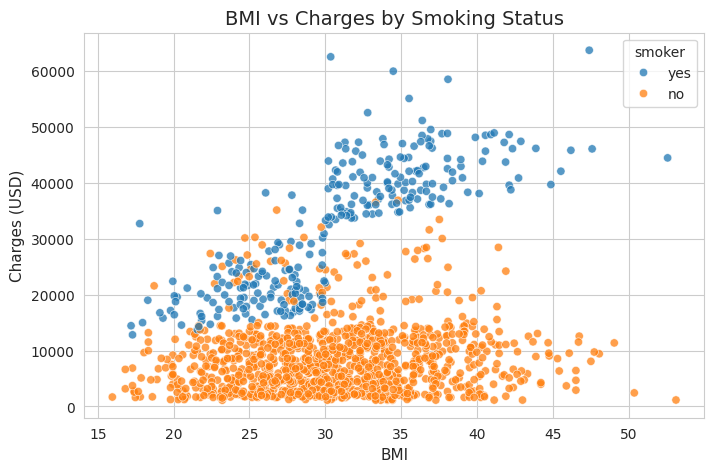

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.75)
plt.title('BMI vs Charges by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.show()

BMI by itself seems, spread widely, however, separating out smokers and non-smokers appear to reveal a positive correlation with charges for smokers.

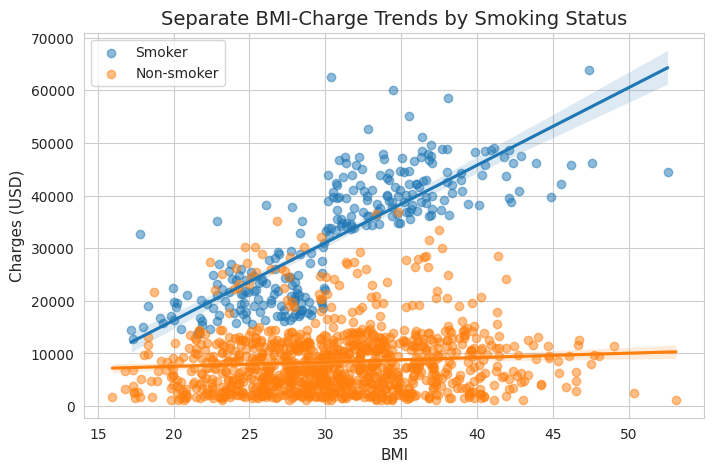

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df[df['smoker'] == 'yes'],
    x='bmi', y='charges',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'tab:blue'},
    label='Smoker'
)

sns.regplot(
    data=df[df['smoker'] == 'no'],
    x='bmi', y='charges',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'tab:orange'},
    label='Non-smoker'
)

plt.title('Separate BMI-Charge Trends by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.legend()
plt.show()


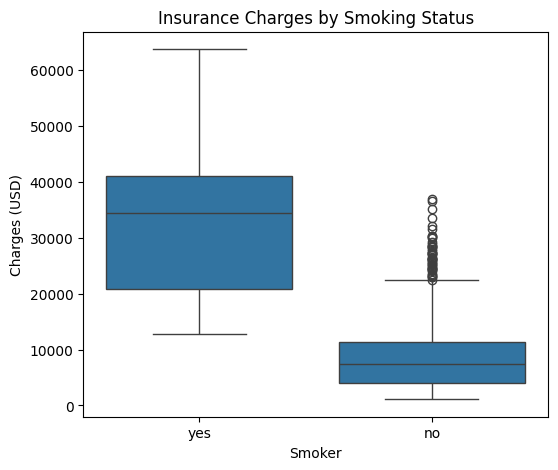

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges (USD)')
plt.show()

The boxplot shows that smokers have substantially higher insurance charges than non‑smokers, with both the median and upper quartiles much larger for smokers and more extreme high‑cost outliers.

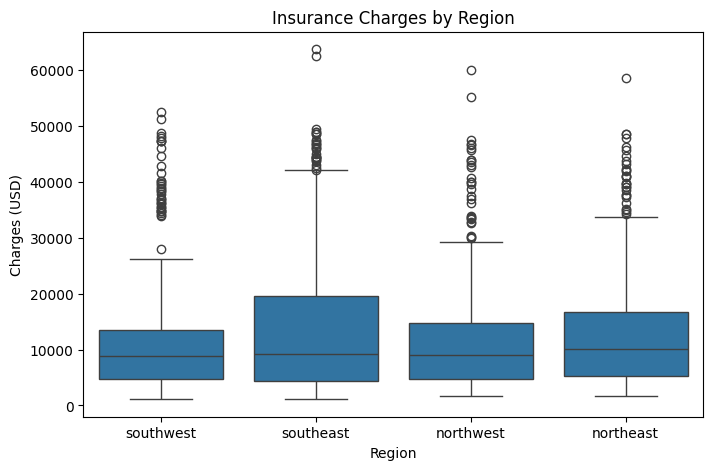

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges (USD)')
plt.show()

Charges are relatively similar across regions, with only small differences in medians and spread, suggesting that region has a weaker effect on insurance costs compared to other factors like smoking.



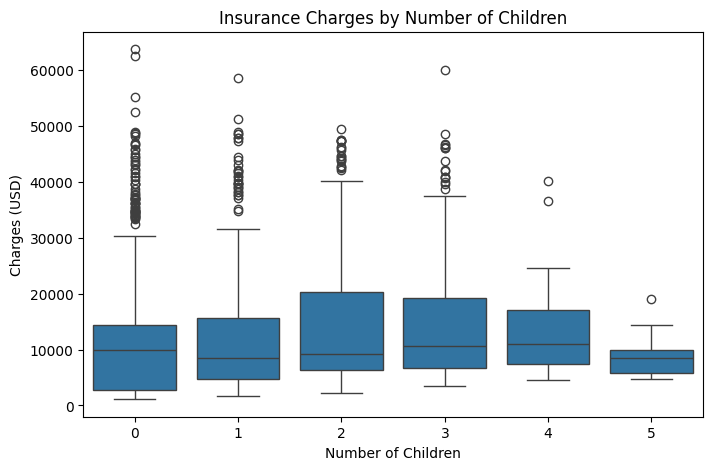

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='children', y='charges', data=df)
plt.title('Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Charges (USD)')
plt.show()

The distribution of charges by number of children shows only modest differences between groups, indicating that the number of dependents has a relatively small effect on insurance charges. The spread appears smaller for 5 children with the values concentrated n the region less than 20000 USD

### Correlation wih charges and smoking

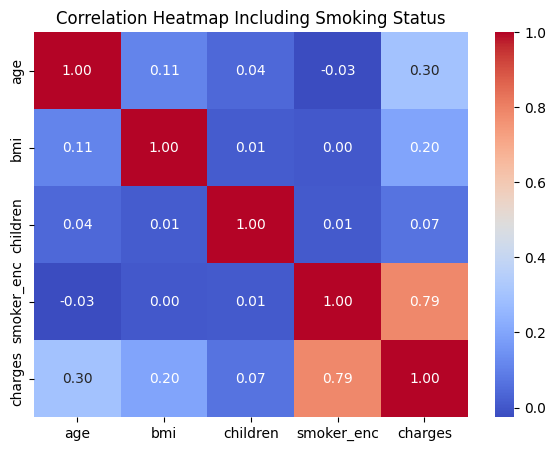

In [ ]:
df_enc = df.copy()
df_enc['smoker_enc'] = df_enc['smoker'].map({'no': 0, 'yes': 1})
corr2 = df_enc[['age', 'bmi', 'children', 'smoker_enc', 'charges']].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr2, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap Including Smoking Status')
plt.show()

In [ ]:
df_nonsmokers = df[df['smoker'] == 'no']
df_smokers = df[df['smoker'] == 'yes']


In [ ]:
features = ['age', 'bmi', 'children']

corr_smokers  = df_smokers[features + ['charges']].corr()['charges'].drop('charges')
corr_nonsmokers = df_nonsmokers[features + ['charges']].corr()['charges'].drop('charges')

corr_compare = pd.DataFrame({
    'smokers': corr_smokers,
    'non_smokers': corr_nonsmokers
})


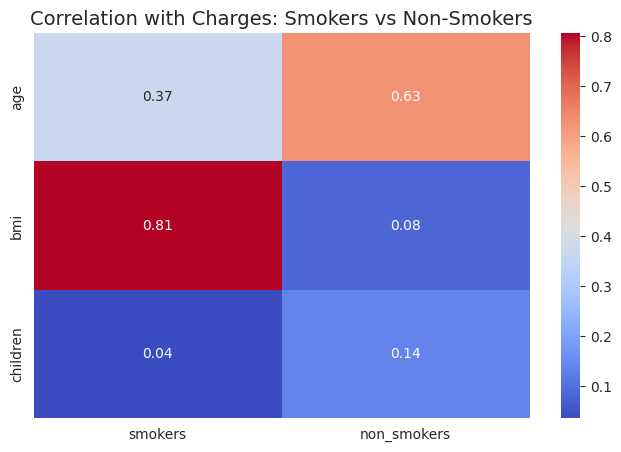

In [ ]:
plt.figure()
sns.heatmap(corr_compare, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with Charges: Smokers vs Non-Smokers')
plt.show()

Separating smokers and non-smokers reveals different patterns. Among smokers, BMI has a strong positive relationship with charges, while among non-smokers the relationship between BMI and charges is much weaker and age appears more relevant. This suggests that a single global trend line would hide meaningful structure in the data.

## Part 5 - Data preprocessing and feature engineering

To prepare the data for linear regression, categorical variables are encoded and an interaction term between BMI and smoking status is added. This interaction term allows the effect of BMI to differ between smokers and non-smokers.


In [ ]:
X = df.drop('charges', axis=1)  # features
y = df['charges']               # target

In [ ]:
X_encoded = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)
X_encoded['bmi_smoker_inter'] = X_encoded['bmi'] * X_encoded['smoker_yes']
X_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_smoker_inter
0,19,27.900,0,False,True,False,False,True,27.9
1,18,33.770,1,True,False,False,True,False,0.0
2,28,33.000,3,True,False,False,True,False,0.0
3,33,22.705,0,True,False,True,False,False,0.0
4,32,28.880,0,True,False,True,False,False,0.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

In [ ]:
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Missing values in X_train:')
print(X_train.isnull().sum())

X_train shape: (935, 9)
X_test shape: (402, 9)
Missing values in X_train:
age                 0
bmi                 0
children            0
sex_male            0
smoker_yes          0
region_northwest    0
region_southeast    0
region_southwest    0
bmi_smoker_inter    0
dtype: int64


## Part 6 - Model training

A multiple linear regression model is trained using the processed feature set.


In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

## Part 7 - Model evaluation

The model is evaluated on the test set using MAE, MSE, RMSE, and \(R^2\).

In [ ]:
y_pred = lin_reg.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.3f}")

MAE  : 2909.67
MSE  : 25038643.82
RMSE : 5003.86
R^2  : 0.854


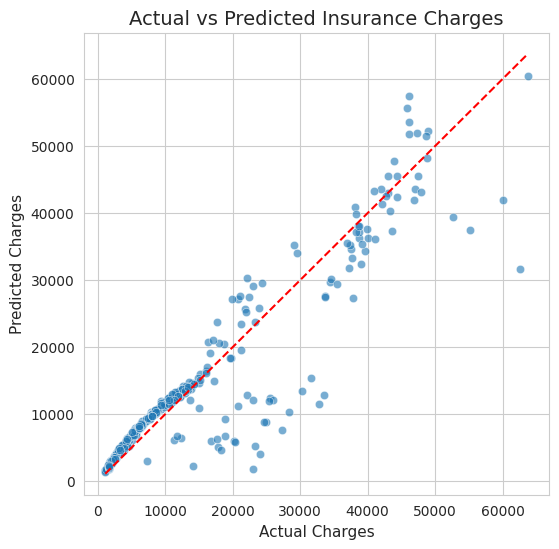

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.show()

If the model performs well, points should cluster around the 45-degree reference line. Deviations from that line indicate prediction error.


## Part 8 - Coefficient interpretation

Model coefficients help identify which variables have the largest estimated effect on predicted charges, holding the other variables constant.


In [ ]:
coef_series = pd.Series(lin_reg.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
coef_series.head(10)

,0
smoker_yes,-22158.237184
bmi_smoker_inter,1490.234681
region_southeast,-890.768339
region_southwest,-843.202479
sex_male,-709.000979
children,568.270428
region_northwest,-400.849028
age,264.429673
bmi,17.169146


In [ ]:
coef_series = pd.Series(lin_reg.intercept_, index=X_train.columns).sort_values(key=abs, ascending=False)
coef_series.head(10)

,0
age,-2222.255117
bmi,-2222.255117
children,-2222.255117
sex_male,-2222.255117
smoker_yes,-2222.255117
region_northwest,-2222.255117
region_southeast,-2222.255117
region_southwest,-2222.255117
bmi_smoker_inter,-2222.255117


In [ ]:
intercept = lin_reg.intercept_
print(f'Intercept: {intercept:,.2f}')


Intercept: -2,222.26


Smoking status and the BMI-smoking interaction term have the largest coefficients in magnitude. This means smoking status is the strongest predictor in the model, and the positive interaction term indicates that increases in BMI are associated with much larger increases in charges for smokers than for non-smokers.

he region coefficients are relatively small compared with smoking-related effects, suggesting that location contributes less to prediction in this dataset. The coefficients should be interpreted carefully because interaction terms change the meaning of the individual main-effect coefficients. For example, the coefficient of smoker_yes does not represent the full smoker effect on its own once the BMI interaction is included.

## Part 9 - Conclusion

The goal of this project was to analyze the `insurance.csv` dataset and build a linear regression model that predicts medical insurance charges using age, sex, BMI, number of children, smoking status, and region. The analysis followed a structured workflow that included data inspection, cleaning, exploratory visualization, preprocessing, model training, and interpretation.

The exploratory analysis showed that smoking status is the most important driver of insurance charges. In addition, the relationship between BMI and charges differs strongly between smokers and non-smokers. Smokers tend to have much higher charges overall, and the increase in charges with BMI is substantially steeper in the smoker group. This justified adding an interaction term between BMI and smoking status.

The linear regression model performed reasonably well on the test set, indicating that the selected variables explain a large proportion of the variation in charges. Among the model features, smoking status and the BMI-smoking interaction had the strongest influence, while age also contributed positively and region had a comparatively small effect.

Overall, the project shows that a relatively simple regression model can capture much of the structure in the insurance dataset, especially when feature engineering is guided by exploratory analysis. A useful next step would be to compare this model with nonlinear or tree-based models and to test whether a log transformation of charges improves predictive performance further.


### Business Insights



*   For an insurer, smoking status is a major risk factor. Smokers represent a much higher‑cost group and would typically justify higher premiums, stricter underwriting, or targeted wellness/cessation programs to manage this risk.
*  Age is a predictable, steady risk factor. As customers grow older, their expected medical costs rise, so age‑based pricing tiers or age‑adjusted premiums are justified. However, age alone does not explain extreme high‑cost cases as strongly as smoking and BMI.
* Excess weight is a risk factor on its own, but it becomes particularly costly when combined with smoking. From a business perspective, interventions that target weight management among smokers (e.g., combined smoking‑cessation and lifestyle programs) are likely to have the biggest impact on reducing claims.

* For this dataset, geography is not a major driver of individual medical costs compared with personal risk factors like smoking, BMI, and age. An insurer might still differentiate products by region for other reasons (local provider networks, regulations), but pure medical risk in this data is not strongly region‑dependent.
